In [0]:
import sqlite3
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

In [0]:
db_path_warehouse = "/Workspace/Users/jonathashonorio@gmail.com/Projeto_Seguros/data_warehouse.db"
data_path = "/Volumes/workspace/ey_academy/dados_analisados"

In [0]:
db_path_warehouse = "/Workspace/Users/jonathashonorio@gmail.com/Projeto_Seguros/data_warehouse.db"
 
# Nome da tabela que você quer ler
table_name = "indicadores_criminiladidade"

# Conectando ao banco
conn = sqlite3.connect(db_path_warehouse)
 
# Lendo apenas a tabela desejada
df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
 
# Fechando a conexão
conn.close()
 
# Exibindo o DataFrame
display(df)

uf,tipo_crime,ano,mes,ocorrencias
Acre,Furto de veículo,2018,janeiro,74
Acre,Roubo de veículo,2018,janeiro,110
Acre,Furto de veículo,2018,fevereiro,56
Acre,Roubo de veículo,2018,fevereiro,59
Acre,Furto de veículo,2018,março,37
Acre,Roubo de veículo,2018,março,48
Acre,Furto de veículo,2018,abril,44
Acre,Roubo de veículo,2018,abril,53
Acre,Furto de veículo,2018,maio,43
Acre,Roubo de veículo,2018,maio,87


Agrupamento por regiões no ano de 2019 e manter meses para rodar um grafo para vermos por meses  
Tentativa de agrupamento de roubos e furtos para aplicar o /\ no grafo também  
Agrupamento por ano fechado para aplicação  
qual tipo tem mais sinistro


In [0]:
# Coluna de Região 

regioes = {
    'Norte': [
        'Acre', 'Amapá', 'Amazonas', 'Pará', 'Rondônia', 'Roraima', 'Tocantins'
    ],
    'Nordeste': [
        'Alagoas', 'Bahia', 'Ceará', 'Maranhão', 'Paraíba', 'Pernambuco', 'Piauí', 'Rio Grande do Norte', 'Sergipe'
    ],
    'Centro-Oeste': [
        'Goiás', 'Mato Grosso', 'Mato Grosso do Sul', 'Distrito Federal'
    ],
    'Sudeste': [
        'Espírito Santo', 'Minas Gerais', 'Rio de Janeiro', 'São Paulo'
    ],
    'Sul': [
        'Paraná', 'Rio Grande do Sul', 'Santa Catarina'
    ]
}

def map_regiao(uf):
    for regiao, estados in regioes.items():
        if uf in estados:
            return regiao
    return 'Outros'


map_regiao_udf = F.udf(map_regiao)

df = spark.createDataFrame(df)
df = df.withColumn('regiao', map_regiao_udf(F.col('uf')))

display(df)


uf,tipo_crime,ano,mes,ocorrencias,regiao
Acre,Furto de veículo,2018,janeiro,74,Norte
Acre,Roubo de veículo,2018,janeiro,110,Norte
Acre,Furto de veículo,2018,fevereiro,56,Norte
Acre,Roubo de veículo,2018,fevereiro,59,Norte
Acre,Furto de veículo,2018,março,37,Norte
Acre,Roubo de veículo,2018,março,48,Norte
Acre,Furto de veículo,2018,abril,44,Norte
Acre,Roubo de veículo,2018,abril,53,Norte
Acre,Furto de veículo,2018,maio,43,Norte
Acre,Roubo de veículo,2018,maio,87,Norte


In [0]:
# Total por tipo de crime por ano

roubo = (
    df.groupBy("ano", "tipo_crime")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy("ano")
)

display(roubo)

total = roubo.agg(F.sum("qtd_crimes").alias("total"))
display(total)

ano,tipo_crime,qtd_crimes
2018,Roubo de veículo,244954
2018,Furto de veículo,241500
2019,Furto de veículo,219381
2019,Roubo de veículo,184729


total
890564


In [0]:
# Total por tipo de crime por região e por ano

roubo = (
    df.groupBy("ano", "tipo_crime", "regiao")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy("ano", "tipo_crime", "regiao")
)

display(roubo)

total = roubo.agg(F.sum("qtd_crimes").alias("total"))
display(total)

ano,tipo_crime,regiao,qtd_crimes
2018,Furto de veículo,Centro-Oeste,22293
2018,Furto de veículo,Nordeste,25630
2018,Furto de veículo,Norte,13121
2018,Furto de veículo,Sudeste,139296
2018,Furto de veículo,Sul,41160
2018,Roubo de veículo,Centro-Oeste,16802
2018,Roubo de veículo,Nordeste,62903
2018,Roubo de veículo,Norte,14632
2018,Roubo de veículo,Sudeste,124407
2018,Roubo de veículo,Sul,26210


total
890564


In [0]:
# Total de crimes por região e por ano

crime_regiao = (
    df.groupBy("ano", "regiao")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy(F.desc("qtd_crimes"))
)

display(crime_regiao)

total = crime_regiao.agg(F.sum("qtd_crimes").alias("total"))
display(total)

ano,regiao,qtd_crimes
2018,Sudeste,263703
2019,Sudeste,222072
2018,Nordeste,88533
2019,Nordeste,73754
2018,Sul,67370
2019,Sul,56567
2018,Centro-Oeste,39095
2019,Centro-Oeste,29819
2018,Norte,27753
2019,Norte,21898


total
890564


In [0]:
from pyspark.sql import functions as F

# =========================
# 1) Filtra 2019 e agrega por região
# =========================
crime_regiao_2019 = (
    df.filter(F.col("ano") == 2019)
      .groupBy("regiao")
      .agg(F.sum("ocorrencias").alias("qtd_crimes"))
      .orderBy(F.desc("qtd_crimes"))
)

display(crime_regiao_2019)

# =========================
# 2) Total geral em 2019
# =========================
total_2019 = crime_regiao_2019.agg(F.sum("qtd_crimes").alias("total"))
display(total_2019)

regiao,qtd_crimes
Sudeste,222072
Nordeste,73754
Sul,56567
Centro-Oeste,29819
Norte,21898


total
404110


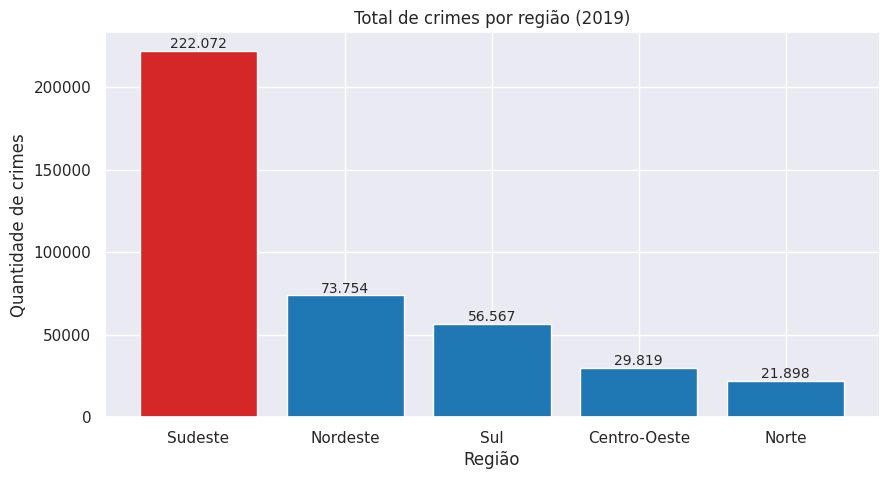

In [0]:
# Converter para Pandas
pdf = crime_regiao_2019.toPandas()

sns.set_theme(style="darkgrid")

# Identifica a posição da maior coluna
max_pos = pdf["qtd_crimes"].values.argmax()

# Cores: padrão azul; a maior fica vermelha
colors = ["#1f77b4"] * len(pdf)
colors[max_pos] = "#d62728"  # vermelho

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(pdf["regiao"], pdf["qtd_crimes"], color=colors)

# Anota os valores acima de cada barra
for i, v in enumerate(pdf["qtd_crimes"]):
    plt.text(i, v, f"{int(v):,}".replace(",", "."), ha="center", va="bottom", fontsize=10)

plt.title("Total de crimes por região (2019)")
plt.xlabel("Região")
plt.ylabel("Quantidade de crimes")
plt.xticks(rotation=0)

plt.show()

In [0]:
# Total de ROUBO de veículo por estado em 2018 e 2019

roubo_estado = (
    df.filter(F.col("tipo_crime")=="Roubo de veículo")
    .groupBy("tipo_crime", "uf")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy(F.desc("qtd_crimes"), "tipo_crime", "uf")
)

display(roubo_estado)


total = roubo_estado.agg(F.sum("qtd_crimes").alias("total"))
display(total)

tipo_crime,uf,qtd_crimes
Roubo de veículo,São Paulo,104868
Roubo de veículo,Rio de Janeiro,91847
Roubo de veículo,Pernambuco,28454
Roubo de veículo,Rio Grande do Sul,27246
Roubo de veículo,Bahia,24871
Roubo de veículo,Minas Gerais,15624
Roubo de veículo,Goiás,14955
Roubo de veículo,Ceará,14447
Roubo de veículo,Paraná,13659
Roubo de veículo,Rio Grande do Norte,11495


total
429683


In [0]:
# Total de FURTO de veículo por estado em 2018 e 2019

from pyspark.sql.functions import format_number, concat, lit

furto_estado = (
    df.filter(F.col("tipo_crime")=="Furto de veículo")
    .groupBy("tipo_crime", "uf")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy(F.desc("qtd_crimes"), "tipo_crime", "uf")
)

display(furto_estado)


total = furto_estado.agg(F.sum("qtd_crimes").alias("total"))
display(total)

tipo_crime,uf,qtd_crimes
Furto de veículo,São Paulo,181752
Furto de veículo,Minas Gerais,41858
Furto de veículo,Paraná,33587
Furto de veículo,Rio de Janeiro,31388
Furto de veículo,Rio Grande do Sul,27512
Furto de veículo,Goiás,19544
Furto de veículo,Santa Catarina,17997
Furto de veículo,Pernambuco,11524
Furto de veículo,Bahia,10621
Furto de veículo,Espírito Santo,10048


total
460881


In [0]:
# Porcentagem de FURTO de veículo por estado em 2018

from pyspark.sql.functions import format_number, concat, lit, round

furto_2018 = (
    df.filter((F.col("ano") == "2018") & (F.col("tipo_crime") == "Furto de veículo"))
    .groupBy("ano", "tipo_crime", "uf")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy(F.desc("qtd_crimes"))
)

total_furto_2018 = furto_2018.agg(F.sum("qtd_crimes").alias("total")).collect()[0]["total"]

furto_2018_percentual = furto_2018.withColumn(
    "percentual",
    concat(format_number((F.col("qtd_crimes") / F.lit(total_furto_2018)) * 100, 2), lit("%"))
)

display(furto_2018_percentual)


ano,tipo_crime,uf,qtd_crimes,percentual
2018,Furto de veículo,São Paulo,97653,40.44%
2018,Furto de veículo,Minas Gerais,21401,8.86%
2018,Furto de veículo,Paraná,17620,7.30%
2018,Furto de veículo,Rio de Janeiro,15794,6.54%
2018,Furto de veículo,Rio Grande do Sul,14407,5.97%
2018,Furto de veículo,Goiás,11267,4.67%
2018,Furto de veículo,Santa Catarina,9133,3.78%
2018,Furto de veículo,Pernambuco,5387,2.23%
2018,Furto de veículo,Bahia,5332,2.21%
2018,Furto de veículo,Distrito Federal,4888,2.02%


In [0]:
# Porcentagem de ROUBO de veículo por estado em 2018

roubo_2018 = (
    df.filter((F.col("ano") == "2018") & (F.col("tipo_crime") == "Roubo de veículo"))
    .groupBy("ano", "tipo_crime", "uf")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy(F.desc("qtd_crimes"))
)

total_roubo_2018 = roubo_2018.agg(F.sum("qtd_crimes").alias("total")).collect()[0]["total"]

roubo_2018_percentual = roubo_2018.withColumn(
    "percentual", 
    concat(format_number((F.col("qtd_crimes") / F.lit(total_roubo_2018)) * 100, 2), lit("%")) 
)

display(roubo_2018_percentual)

ano,tipo_crime,uf,qtd_crimes,percentual
2018,Roubo de veículo,São Paulo,58355,23.82%
2018,Roubo de veículo,Rio de Janeiro,52097,21.27%
2018,Roubo de veículo,Rio Grande do Sul,16121,6.58%
2018,Roubo de veículo,Pernambuco,15327,6.26%
2018,Roubo de veículo,Bahia,13348,5.45%
2018,Roubo de veículo,Goiás,10163,4.15%
2018,Roubo de veículo,Minas Gerais,9522,3.89%
2018,Roubo de veículo,Ceará,9319,3.80%
2018,Roubo de veículo,Paraná,7870,3.21%
2018,Roubo de veículo,Rio Grande do Norte,6982,2.85%


In [0]:
# Porcentagem de FURTO de veículo por estado em 2019

furto_2019 = (
    df.filter((F.col("ano") == "2019") & (F.col("tipo_crime") == "Furto de veículo"))
    .groupBy("ano", "tipo_crime", "uf")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy(F.desc("qtd_crimes"))
)

total_furto_2019 = furto_2019.agg(F.sum("qtd_crimes").alias("total")).collect()[0]["total"]

furto_2019_percentual = furto_2019.withColumn(
    "percentual", 
    concat(format_number((F.col("qtd_crimes") / F.lit(total_furto_2019)) * 100, 2), lit("%")) 
)

display(furto_2019_percentual)

ano,tipo_crime,uf,qtd_crimes,percentual
2019,Furto de veículo,São Paulo,84099,38.33%
2019,Furto de veículo,Minas Gerais,20457,9.32%
2019,Furto de veículo,Paraná,15967,7.28%
2019,Furto de veículo,Rio de Janeiro,15594,7.11%
2019,Furto de veículo,Rio Grande do Sul,13105,5.97%
2019,Furto de veículo,Santa Catarina,8864,4.04%
2019,Furto de veículo,Goiás,8277,3.77%
2019,Furto de veículo,Pernambuco,6137,2.80%
2019,Furto de veículo,Espírito Santo,5600,2.55%
2019,Furto de veículo,Bahia,5289,2.41%


In [0]:
# Porcentagem de ROUBO de veículo por estado em 2019

roubo_2019 = (
    df.filter((F.col("ano") == "2019") & (F.col("tipo_crime") == "Roubo de veículo"))
    .groupBy("ano", "tipo_crime", "uf")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy(F.desc("qtd_crimes"))
)

total_roubo_2019 = roubo_2019.agg(F.sum("qtd_crimes").alias("total")).collect()[0]["total"]

roubo_2019_percentual = roubo_2019.withColumn(
    "percentual",
    concat(format_number((F.col("qtd_crimes") / F.lit(total_roubo_2019)) * 100, 2), lit("%")) 
)

display(roubo_2019_percentual)

ano,tipo_crime,uf,qtd_crimes,percentual
2019,Roubo de veículo,São Paulo,46513,25.18%
2019,Roubo de veículo,Rio de Janeiro,39750,21.52%
2019,Roubo de veículo,Pernambuco,13127,7.11%
2019,Roubo de veículo,Bahia,11523,6.24%
2019,Roubo de veículo,Rio Grande do Sul,11125,6.02%
2019,Roubo de veículo,Minas Gerais,6102,3.30%
2019,Roubo de veículo,Paraná,5789,3.13%
2019,Roubo de veículo,Ceará,5128,2.78%
2019,Roubo de veículo,Goiás,4792,2.59%
2019,Roubo de veículo,Rio Grande do Norte,4513,2.44%


In [0]:
# Porcentagem do tipo de veículo pelo total

crime_tipo = (
    df.groupBy("tipo_crime")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy(F.desc("qtd_crimes"))
)

total_tipo = crime_tipo.agg(F.sum("qtd_crimes").alias("total")).collect()[0]["total"]

crime_tipo_percentual = crime_tipo.withColumn(
    "percentual",
    concat(format_number((F.col("qtd_crimes") / F.lit(total_tipo)) * 100, 2), lit("%")) 
)

display(crime_tipo_percentual)


tipo_crime,qtd_crimes,percentual
Furto de veículo,460881,51.75%
Roubo de veículo,429683,48.25%


In [0]:

crime_regiao = (
    df.groupBy("tipo_crime", "regiao")
    .agg(F.sum("ocorrencias").alias("qtd_crimes"))
    .orderBy(F.desc("qtd_crimes"), "tipo_crime", "regiao")
)

total_regiao = crime_regiao.agg(F.sum("qtd_crimes").alias("total")).collect()[0]["total"]

crime_regiao_percentual = (
    crime_regiao.withColumn(
        "percentual",
        F.concat(F.format_number((F.col("qtd_crimes") / F.lit(total_regiao)) * 100, 2), F.lit("%"))
    )
)

display(crime_regiao_percentual)


tipo_crime,regiao,qtd_crimes,percentual
Furto de veículo,Sudeste,265046,29.76%
Roubo de veículo,Sudeste,220729,24.79%
Roubo de veículo,Nordeste,111226,12.49%
Furto de veículo,Sul,79096,8.88%
Furto de veículo,Nordeste,51061,5.73%
Roubo de veículo,Sul,44841,5.04%
Furto de veículo,Centro-Oeste,41526,4.66%
Roubo de veículo,Centro-Oeste,27388,3.08%
Roubo de veículo,Norte,25499,2.86%
Furto de veículo,Norte,24152,2.71%


In [0]:
from pyspark.sql import functions as F

# 1) Normaliza e filtra apenas roubo/furto
df_rf = (
    df.withColumn("tipo_crime_norm", F.lower(F.col("tipo_crime")))
      .filter(F.col("tipo_crime_norm").isin("roubo", "furto"))
)

# 2) TOTAL POR REGIÃO (todos os anos somados)
total_por_regiao = (
    df_rf.groupBy("regiao")
         .agg(F.sum("ocorrencias").alias("total_crimes_regiao"))
         .orderBy("regiao")
)

display(total_por_regiao)

# 3) (Opcional) TOTAL POR ANO E REGIÃO
total_ano_regiao = (
    df_rf.groupBy("ano", "regiao")
         .agg(F.sum("ocorrencias").alias("qtd_crimes"))
         .orderBy("ano", "regiao")
)

# Comente a linha abaixo se não precisar desta visão
display(total_ano_regiao)

# 4) (Opcional) Se quiser também ver o total geral (todas as regiões e anos)
total_geral = total_por_regiao.agg(F.sum("total_crimes_regiao").alias("total_geral"))
display(total_geral)

regiao,total_crimes_regiao


ano,regiao,qtd_crimes


total_geral
null
